# Exercise 1: Decision Tree Classifier (30 points)

In this exercise we will train a decision tree classifier for neutrino experiment data from [the MiniBOONE experiment](https://www.fnal.gov/pub/science/experiments/intensity/miniboone.html).

The goal is to prepare a binary classification to distinguish electron neutrinos (signal) from muon neutrinos (background). The dataset is taken from the UCI ML dataset repository.

In [10]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.metrics import confusion_matrix, roc_curve, auc
import numpy as np
import matplotlib.pyplot as plt

data = fetch_openml("miniboone", parser="auto", version=1)
X, y = data["data"].values, (data["target"].values == "True").astype(float)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

## part 1(a): Data Exploration and Visualization (10 points)

Explore the dataset before building your ML classifier:
- How many events are in the training data and testing data?
- How many input features are there for each point in the training data?
- Plot at least three of the input features for events with `y_train==0` and for events with `y_train==1`.

Training events: 104051
Test events: 26013
Number of features: 50


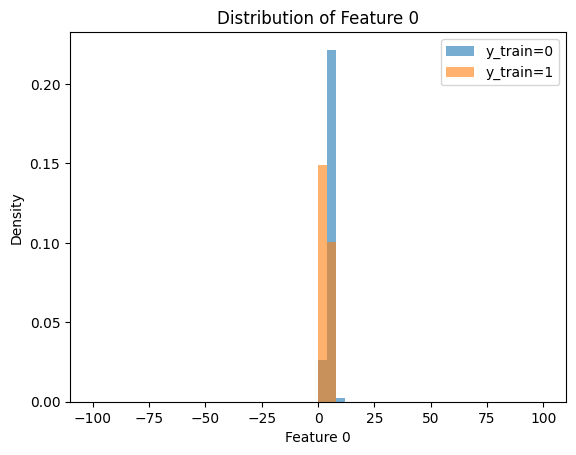

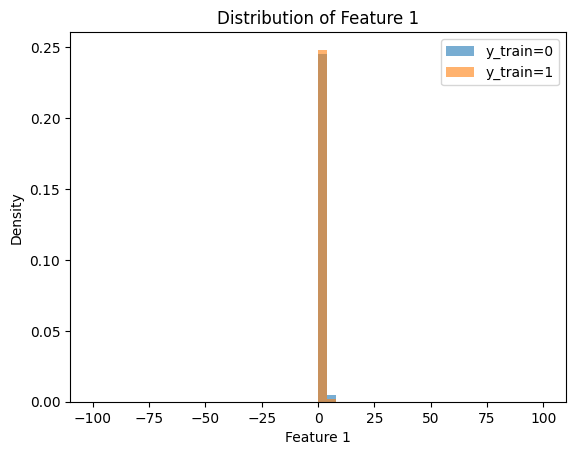

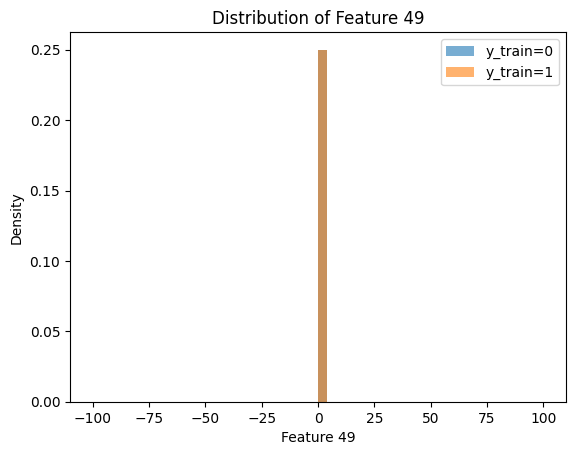

In [2]:
# Add code here to explore the dataset

# To see how many events
print("Training events:", X_train.shape[0])
print("Test events:", X_test.shape[0])

# Features print
print("Number of features:", X_train.shape[1])

# 3 feature plot
feature_indexs = [0, 1, 49] ## Since the number of features is 50, indexs > 50 will crash

for j in feature_indexs:
    x_0 = X_train[y_train == 0, j]  #background values
    x_1 = X_train[y_train == 1, j]  #signal values

    plt.figure()
    #plt.hist(x_0, bins=50, alpha=0.6, density=True, label="y_train=0")  
    #plt.hist(x_1, bins=50, alpha=0.6, density=True, label="y_train=1")
    ## Noticed outlier on far left, wonder if they are place holders. 
    ## Decided to zoom in to see the majority of the data distribution
    plt.hist(x_0, bins=50, range=(-100,100), alpha=0.6, density=True, label="y_train=0")
    plt.hist(x_1, bins=50, range=(-100,100), alpha=0.6, density=True, label="y_train=1")
    plt.xlabel(f"Feature {j}")
    plt.ylabel("Density")
    plt.title(f"Distribution of Feature {j}")
    plt.legend()
    plt.show()

## Result for 1(a)
- Feature 0 shows background slightly more sharply peaked, slightly broader, weak differences.
- Feature 1 is almost identical distribution.
- Feature 49 is nearly indistinguishable.

## part 1(b): Decision Tree (10 points)

Train a simple `DecisionTreeClassifier` with `max_depth=5` and the `gini` criterion to separate the electron neutrino signal and muon neutrino background.

Calculate the performance of the Decision Tree:
- confusion matrix
- ROC curve
- Area Under Curve (AUC)


Confusion Matrix:
[[17567  1091]
 [ 1738  5617]]


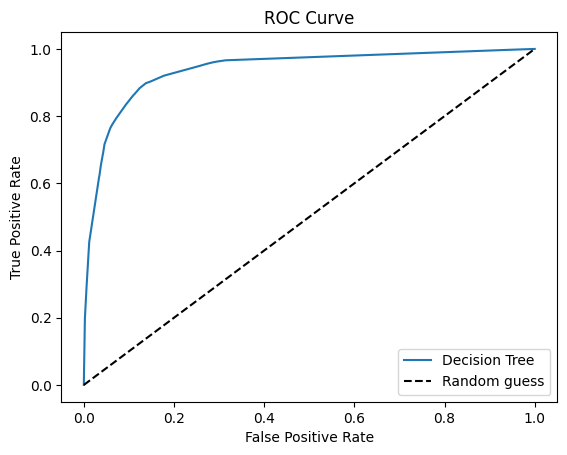

AUC: 0.9380973010266955


In [8]:
# Add code here to train the DecisionTreeClassifier and assess its performance

# Training without test data, using required parameters
dt = DecisionTreeClassifier(
    max_depth=5,
    criterion="gini",
    random_state=0
)

dt.fit(X_train, y_train)

# Predictions
y_pred = dt.predict(X_test) #class prediction 0 or 1
y_score = dt.predict_proba(X_test)[:, 1] # probability of class y-1 signal

# confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

# plot of true postive rate Vs. false postive rate
fpr, tpr, thresholds = roc_curve(y_test, y_score)

plt.figure()
plt.plot(fpr, tpr, label="Decision Tree")
plt.plot([0, 1], [0, 1], "k--", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

#AUC score, expect output > 0.5(random), close to 1.0 for good datasets
roc_auc = auc(fpr, tpr)
print("AUC:", roc_auc)


- Matrix shows 17567 true negatives and 5617 true positives, off diagonal numbers are 1091 and 1738 as misclassifications. ROC curve shows a curve, climbs high toward the top left corner, pretty goo at separating between signal and background. Final AUC score with near 0.94 proves it.

## part 1(c): Gini impurity measure

Visualize the decision tree, and pick three of the leaf nodes in your decision tree visualization.

For each node, calculate the Gini impurity by hand to check against the calculation from scikit-learn. Show the steps of your calculation and the result.

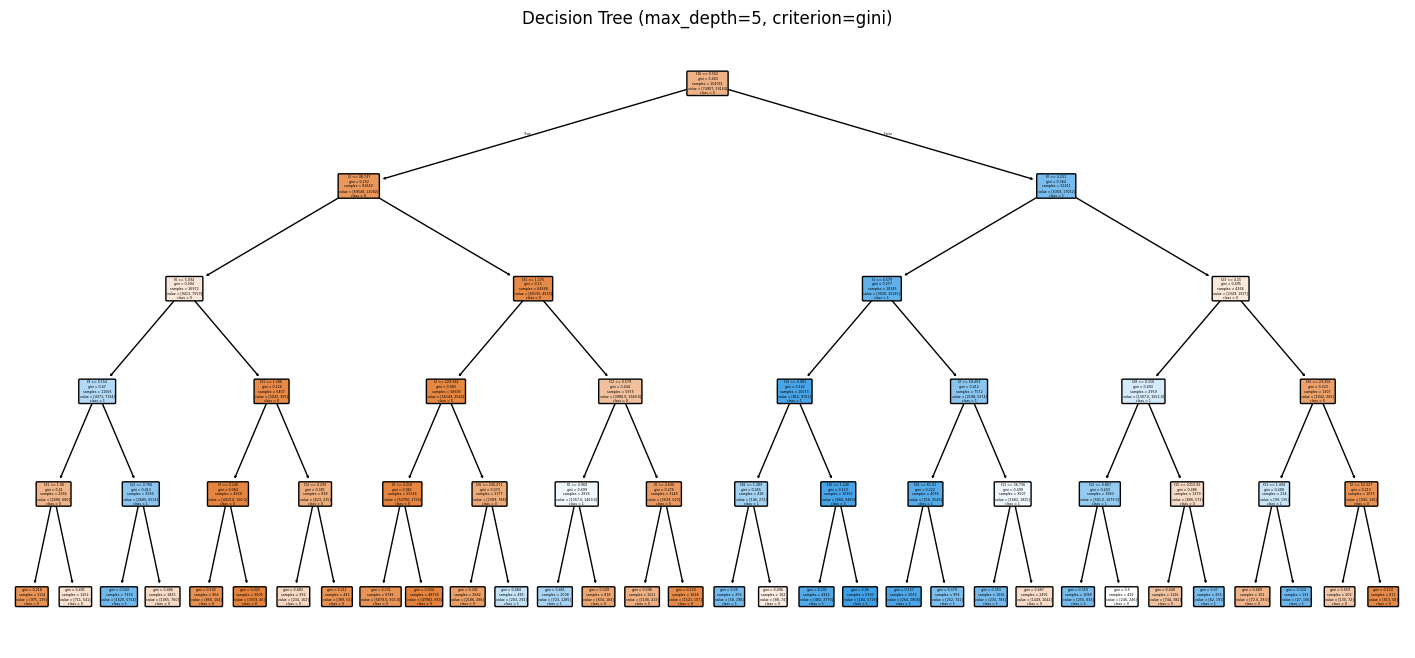

In [17]:
# Add code to visualize the decision tree and get impurity measures

# plot the traained decision tree
plt.figure(figsize=(18, 8))
plot_tree(
    dt,                       # trained DecisionTreeClassifier from 1(b)
    max_depth=5,              # full tree with depth=5, lower for visualization
    filled=True,              # color nodes by purity
    rounded=True,
    feature_names=[f"f{i}" for i in range(X_train.shape[1])],  # f0 to f49
    class_names=["0", "1"],   # background=0, signal=1
    proportion=False          # show counts
)
plt.title("Decision Tree (max_depth=5, criterion=gini)")
plt.show()

## Tree shows 5 depth
Gini impurity 
$$
G = 1 - (p_0^2 + p_1^2)
$$

- p0 is probability of class 0 muon in the node, and p1 is electron.

In [26]:
leaf_indices = np.where(dt.tree_.children_left == -1)[0]
selected_leaves = leaf_indices[:3] # Taking first three leaf nodes

print("Data for Manual Gini Calculation")
for i, idx in enumerate(selected_leaves):
    counts = dt.tree_.value[idx][0] # Extract class counts at this leaf
    n0 = counts[0]  # muon
    n1 = counts[1]  # electron
    n_tot = n0 + n1

    # Convert counts to probabilities
    p0 = n0 / n_tot
    p1 = n1 / n_tot

    gini_manual = 1.0 - (p0**2 + p1**2)

    # Compare to sklearn
    sklearn_gini = dt.tree_.impurity[idx]

    print(f"Leaf Node {i+1} (Node ID {idx}):")
    print(f"  Counts: [Muon: {n0:.2f}, Electron: {n1:.2f}]") # got 0 in counts at first, realize have to print float to show an accurate value.
    print(f"  Probabilities: p0={p0:.4f}, p1={p1:.4f}")
    print(f"  Gini (manual):    {gini_manual:.6f}")
    print(f"  Gini (sklearn):   {sklearn_gini:.6f}")
    print(f"  Difference:       {abs(gini_manual - sklearn_gini):.2e}")


Data for Manual Gini Calculation
Leaf Node 1 (Node ID 5):
  Counts: [Muon: 0.88, Electron: 0.12]
  Probabilities: p0=0.8752, p1=0.1248
  Gini (manual):    0.218413
  Gini (sklearn):   0.218413
  Difference:       0.00e+00
Leaf Node 2 (Node ID 6):
  Counts: [Muon: 0.57, Electron: 0.43]
  Probabilities: p0=0.5679, p1=0.4321
  Gini (manual):    0.490782
  Gini (sklearn):   0.490782
  Difference:       0.00e+00
Leaf Node 3 (Node ID 8):
  Counts: [Muon: 0.22, Electron: 0.78]
  Probabilities: p0=0.2197, p1=0.7803
  Gini (manual):    0.342854
  Gini (sklearn):   0.342854
  Difference:       1.11e-16


# Exercise 2: Backpropagation (30 points)

In this exercise you will gain some experience with the backpropagation equations and the numerical calculations of the gradient.



## part 2(a): Backpropagation theory (15 points)

Complete the proofs of [Nielsen's equations BP3 and BP4](http://neuralnetworksanddeeplearning.com/chap2.html#proof_of_the_four_fundamental_equations_(optional)).

In Nielsen's notation (but with layer numbers written in parenthesis for clarity):
$$
\begin{align}
\frac{\partial C}{\partial b_j^{(l)}} &= \delta_j^{(l)} & \quad \quad \text{(BP3)} \\
\frac{\partial C}{\partial w_{jk}^{(l)}} &= a_k^{(l-1)} \delta_j^{(l)} & \quad \quad \text{(BP4)}
\end{align}
$$
where $C$ is the cost function (loss function), $w$ and $b$ are weights and biases, $a$ is the post-activation output for the layer, and $\delta$ is the error of a single neuron.

## BP3
$$
\begin{align}
\textbf{ Chain rule:}\quad 
\frac{\partial C}{\partial b_j^{(l)}} 
&= \frac{\partial C}{\partial z_j^{(l)}} \, \frac{\partial z_j^{(l)}}{\partial b_j^{(l)}} \\
\textbf{ Since } z_j^{(l)}=\sum_k w_{jk}^{(l)}a_k^{(l-1)}+b_j^{(l)} \textbf{thus,}\quad
\frac{\partial z_j^{(l)}}{\partial b_j^{(l)}} 
&= 1 \\
\textbf{ Therefore:}\quad
\frac{\partial C}{\partial b_j^{(l)}} 
&= \frac{\partial C}{\partial z_j^{(l)}} 
= \delta_j^{(l)} \qquad
\end{align}
$$


## BP4
$$
\begin{align}
\textbf \quad
\frac{\partial C}{\partial w_{jk}^{(l)}}
&=
\frac{\partial C}{\partial z_j^{(l)}}
\frac{\partial z_j^{(l)}}{\partial w_{jk}^{(l)}} \\
&=
\frac{\partial C}{\partial z_j^{(l)}} \, a_k^{(l-1)} \\
&=
a_k^{(l-1)} \, \delta_j^{(l)}
\qquad\qquad
\end{align}
$$


## part 2(b): Numerical calculation (15 points)

Consider a single perceptron node with 1-dimensional input $x$. The weight and bias of the node are $w=0.5$ and $b=0.1$. We use the ReLU activation function on the output of the node and the mean square error loss function.

If the data input and target are $x=1, y=1$:
- What is the loss function value?
- What is the gradient $\partial L/\partial w$?
- What is the gradient $\partial L/\partial b$?

You can do this by hand. Show your work, and feel free to check your answer with some code.




# Given
$$
\begin{align}
x &= 1, \quad y = 1, \quad w = 0.5, \quad b = 0.1 \\
z &= wx + b = (0.5)(1)+0.1 = 0.6 \\
\hat{y} &= \mathrm{ReLU}(z) = max(0, 0.6) = 0.6 \\
L &= \frac{1}{2}(\hat{y} - y)^2 = (0.5)(0.6 - 1)^2 = (0.5)(0.16) = 0.08 \\
\end{align}
$$

$$
\begin{align}
\frac{\partial L}{\partial w}
&= \frac{\partial L}{\partial \hat{y}} \frac{\partial \hat{y}}{\partial z} \frac{\partial z}{\partial w} \\
\frac{\partial L}{\partial \hat{y}}
&= \hat{y} - y = 0.6 - 1 = -0.4 \\
\frac{\partial \hat{y}}{\partial z}
&= 1 \qquad  \\
\frac{\partial z}{\partial w}
&= x = 1 \\
\frac{\partial L}{\partial w}
&= (-0.4)(1)(1) \\
&= -0.4
\end{align}
$$

$$
\begin{align}
\frac{\partial L}{\partial b} &= \frac{\partial L}{\partial \hat{y}}
\frac{\partial \hat{y}}{\partial z}
\frac{\partial z}{\partial b} \\
\frac{\partial z}{\partial b} &= 1 \\
\frac{\partial L}{\partial b} &=(-0.4)(1)(1) \\ &= -0.4
\end{align}
$$


# Exercise 3: Deep Neural Networks (40 points)

In this exercise we will train a deep neural network for neutrino experiment data from [the MiniBOONE experiment](https://www.fnal.gov/pub/science/experiments/intensity/miniboone.html).

The goal is similar to Exercise 1 above: prepare a binary classification to distinguish electron neutrinos (signal) from muon neutrinos (background).

In this exercise, you will set up a neural network model using PyTorch and train it using the MiniBOONE training data, then test it on the testing data.

## part 3(a) (20 points): DNN with ReLU activation

Implement a deep neural network (at least 1 hidden layer between the input and output layers) to classify events as electron neutrinos (signal) or muon neutrinos (background). Use the sigmoid activation function.

Here are some starting points for the DNN:
- 3 hidden layers w/ 64 units each
- BCE loss function
- SGD optimizer w/ batch size of 128

You should expect to train for at least 50 epochs.

In [30]:
# Put code here to implement the DNN to classify neutrino events
# You can use the examples from class and the hands-on notebooks

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

#convert numpy arrays to torch tensors
Xtr = torch.tensor(X_train, dtype=torch.float32)
ytr = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)

Xte = torch.tensor(X_test, dtype=torch.float32)
yte = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

#build data loader batchsize = 128
batch_size = 128
train_loader = DataLoader(TensorDataset(Xtr, ytr), batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(TensorDataset(Xte, yte), batch_size=batch_size, shuffle=False)

Using device: cpu


In [34]:
# Define DNN with 3 hidden layers, 64 units each and sig AF
class DNN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.Sigmoid(),            # sigmoid hidden activation

            nn.Linear(64, 64),
            nn.Sigmoid(),

            nn.Linear(64, 64),
            nn.Sigmoid(),

            nn.Linear(64, 1),
            nn.Sigmoid()             # sigmoid output, probability in [0,1]
        )

    def forward(self, x):
        return self.net(x)

input_dim = X_train.shape[1]   # should be 50
model = DNN(input_dim).to(device)
print(model)

# Define loss and optimizer
criterion = nn.BCELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)


# Training loop >= 50 epochs
num_epochs = 50
model.train()

for epoch in range(1, num_epochs + 1):
    running_loss = 0.0

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        yhat = model(xb)          # forward pass
        loss = criterion(yhat, yb)

        optimizer.zero_grad()        # backward pass
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * xb.size(0)

    # average loss over all training samples
    avg_loss = running_loss / len(train_loader.dataset)

    # print epoch
    print("Epoch", epoch, "/", num_epochs, "| Train Loss:", avg_loss)

DNN(
  (net): Sequential(
    (0): Linear(in_features=50, out_features=64, bias=True)
    (1): Sigmoid()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): Sigmoid()
    (4): Linear(in_features=64, out_features=64, bias=True)
    (5): Sigmoid()
    (6): Linear(in_features=64, out_features=1, bias=True)
    (7): Sigmoid()
  )
)
Epoch 1 / 50 | Train Loss: 0.5959237443923153
Epoch 2 / 50 | Train Loss: 0.5925244936855891
Epoch 3 / 50 | Train Loss: 0.5919373093986682
Epoch 4 / 50 | Train Loss: 0.5911921581727417
Epoch 5 / 50 | Train Loss: 0.5902586667843884
Epoch 6 / 50 | Train Loss: 0.588406809884533
Epoch 7 / 50 | Train Loss: 0.5854922890235807
Epoch 8 / 50 | Train Loss: 0.5810817482269803
Epoch 9 / 50 | Train Loss: 0.5734121898278282
Epoch 10 / 50 | Train Loss: 0.5593126539865476
Epoch 11 / 50 | Train Loss: 0.5323228612033041
Epoch 12 / 50 | Train Loss: 0.48635378121731665
Epoch 13 / 50 | Train Loss: 0.43024420240879946
Epoch 14 / 50 | Train Loss: 0.38453705185701675
Ep

## part 3(b) (10 points): DNN performance assessment

Calculate the performance of the DNN on the testing data:
- confusion matrix
- ROC curve
- Area Under Curve (AUC)



Confusion Matrix:
 [[17176  1482]
 [ 1756  5599]]
AUC: 0.9286246428339543


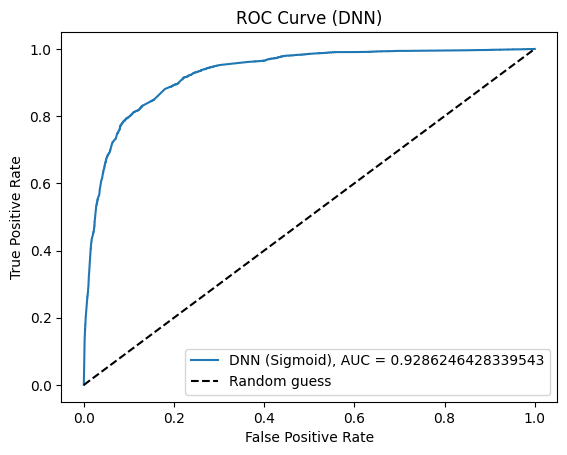

In [38]:
# Put code here to assess the DNN performance
# You can use the examples from class and the hands-on notebooks

with torch.no_grad():
    probs = model(Xte.to(device)).cpu().numpy().ravel()   # probabilities

# convert probabilities to class predictions with threshold 0.5
y_pred = (probs >= 0.5).astype(int)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# ROC and AUC
fpr, tpr, thresholds = roc_curve(y_test, probs)
roc_auc = auc(fpr, tpr)
print("AUC:", roc_auc)

# plot ROC curve
plt.figure()
plt.plot(fpr, tpr, label="DNN (Sigmoid), AUC = " + str(roc_auc))
plt.plot([0, 1], [0, 1], "k--", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (DNN)")
plt.legend()
plt.show()

## Decision tree has slightly higher AUC,both models are strong

## part 3(c) (10 points): Change of activation function

Replace the sigmoid activation functions with the ReLU activation functions, in the layers where it is possible.
(Hint: there is one layer where you can't use the ReLU activation function--why not?)

What happens with the training and performance? Can you improve the performance relative to the original training with sigmoid activation functions?

In [7]:
# Put code here to change the activation functions to sigmoid,
# then retrain and re-assess the performance.
# (It's reasonable to cut-and-paste from the code in part 3(a).)

In [47]:
# # hidden layer ReLU, output layer: sigmoid
# # Define model
# class DNN_ReLU_Output(nn.Module):
#     def __init__(self, input_dim):
#         super().__init__()
#         self.net = nn.Sequential(
#             nn.Linear(input_dim, 64),
#             nn.ReLU(),
#             nn.Linear(64, 64),
#             nn.ReLU(),
#             nn.Linear(64, 64),
#             nn.ReLU(),
#             nn.Linear(64, 1),
#             nn.ReLU()
#         )

#     def forward(self, x):
#         return self.net(x)

# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# input_dim = X_train.shape[1]  # should be 50
# model = DNN_ReLU_Output(input_dim).to(device)

# criterion = nn.BCELoss()

# X_batch = torch.tensor(X_test[:16], dtype=torch.float32).to(device)
# y_batch = torch.tensor(y_test[:16], dtype=torch.float32).view(-1, 1).to(device)

# with torch.no_grad():
#     out = model(X_batch)  

# print("Output stats (ReLU output layer)")
# print("Outputs:\n", out)
# print("Min:", out.min().item(), "Max:", out.max().item())

# print("\n Try BCELoss(out, y)")
# try:
#     loss = criterion(out, y_batch)
#     print("BCELoss:", loss.item())
# except Exception as e:
#     print("BCELoss ERROR:")
#     print(e)

Output stats (ReLU output layer)
Outputs:
 tensor([[0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.]])
Min: 0.0 Max: 0.0

 Try BCELoss(out, y)
BCELoss: 56.25


## ReLU output got stuck at all 0, model is producing constant probility of 0, this makes no sense. Also loss at 56.25 is huge. Keep sigmoid at oiutput

In [48]:
# # reworked
# # hidden layer ReLU, output layer: sigmoid
# # Define model
# class DNN_ReLU_Output(nn.Module):
#     def __init__(self, input_dim):
#         super().__init__()
#         self.net = nn.Sequential(
#             nn.Linear(input_dim, 64),
#             nn.ReLU(),
#             nn.Linear(64, 64),
#             nn.ReLU(),
#             nn.Linear(64, 64),
#             nn.ReLU(),
#             nn.Linear(64, 1),
#             nn.Sigmoid()   #Sigmoid at output
#         )

#     def forward(self, x):
#         return self.net(x)

# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# input_dim = X_train.shape[1]  # should be 50
# model = DNN_ReLU_Output(input_dim).to(device)

# criterion = nn.BCELoss()

# X_batch = torch.tensor(X_test[:16], dtype=torch.float32).to(device)
# y_batch = torch.tensor(y_test[:16], dtype=torch.float32).view(-1, 1).to(device)

# with torch.no_grad():
#     out = model(X_batch)  

# print("Output stats (ReLU output layer)")
# print("Outputs:\n", out)
# print("Min:", out.min().item(), "Max:", out.max().item())

# print("\n Try BCELoss(out, y)")
# try:
#     loss = criterion(out, y_batch)
#     print("BCELoss:", loss.item())
# except Exception as e:
#     print("BCELoss ERROR:")
#     print(e)

Output stats (ReLU output layer)
Outputs:
 tensor([[0.7688],
        [0.6993],
        [0.4161],
        [0.9196],
        [0.8632],
        [0.9745],
        [0.8693],
        [0.2823],
        [0.4867],
        [0.6883],
        [0.9503],
        [0.4623],
        [0.4014],
        [0.9139],
        [0.5867],
        [0.5177]])
Min: 0.2823265790939331 Max: 0.9744734764099121

 Try BCELoss(out, y)
BCELoss: 1.1971746683120728


## Network output is a valid probability for class 1, loss no longer exploding. ReLU can produce invalid probabilities like all 0. Sigmoid output keeps values in (0,1) so BCE can behave normally.

In [49]:
class DNN_ReLU(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),              

            nn.Linear(64, 64),
            nn.ReLU(),

            nn.Linear(64, 64),
            nn.ReLU(),

            nn.Linear(64, 1),
            nn.Sigmoid()            
        )

    def forward(self, x):
        return self.net(x)

input_dim = X_train.shape[1]
model = DNN_ReLU(input_dim).to(device)
print(model)

criterion = nn.BCELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)


num_epochs = 50
model.train()

for epoch in range(1, num_epochs + 1):
    running_loss = 0.0
    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        yhat = model(xb)
        loss = criterion(yhat, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * xb.size(0)

    avg_loss = running_loss / len(train_loader.dataset)
    print("Epoch", epoch, "/", num_epochs, "| Train Loss:", avg_loss)

DNN_ReLU(
  (net): Sequential(
    (0): Linear(in_features=50, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=64, bias=True)
    (5): ReLU()
    (6): Linear(in_features=64, out_features=1, bias=True)
    (7): Sigmoid()
  )
)
Epoch 1 / 50 | Train Loss: 0.7719847680849832
Epoch 2 / 50 | Train Loss: 0.6402983180396284
Epoch 3 / 50 | Train Loss: 0.6324076934524862
Epoch 4 / 50 | Train Loss: 0.6274642313145714
Epoch 5 / 50 | Train Loss: 0.6221160994226361
Epoch 6 / 50 | Train Loss: 0.6175303501523319
Epoch 7 / 50 | Train Loss: 0.6133679275689657
Epoch 8 / 50 | Train Loss: 0.6110955079346919
Epoch 9 / 50 | Train Loss: 0.6089876306258788
Epoch 10 / 50 | Train Loss: 0.6075932582536414
Epoch 11 / 50 | Train Loss: 0.6059358463371126
Epoch 12 / 50 | Train Loss: 0.6036236831699552
Epoch 13 / 50 | Train Loss: 0.6034522027570938
Epoch 14 / 50 | Train Loss: 0.6010146825276058
Epoch 15

Confusion Matrix:
 [[17181  1477]
 [ 1196  6159]]
AUC: 0.9552829021787503


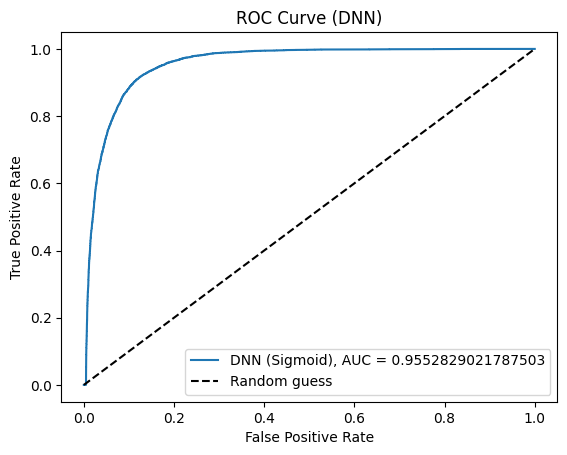

In [50]:
# 3b rerun
with torch.no_grad():
    probs = model(Xte.to(device)).cpu().numpy().ravel()   # probabilities

# convert probabilities to class predictions with threshold 0.5
y_pred = (probs >= 0.5).astype(int)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# ROC and AUC
fpr, tpr, thresholds = roc_curve(y_test, probs)
roc_auc = auc(fpr, tpr)
print("AUC:", roc_auc)

# plot ROC curve
plt.figure()
plt.plot(fpr, tpr, label="DNN (Sigmoid), AUC = " + str(roc_auc))
plt.plot([0, 1], [0, 1], "k--", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (DNN)")
plt.legend()
plt.show()

## Based on the result above, ReLU hidden + Sigmoid output has best result, higher than decision tree and Sigmoid DNN